# IBM Xodimlar Dataseti bo'yicha Exploratory Data Analysis (EDA)

Ushbu notebook IBM xodimlar datasetini chuqur tahlil qiladi.  
**Maqsad:** Xodimlarning ketish (Attrition) sabablarini aniqlash va ma'lumotlarni yaxshi tushunish.

## 1. Kutubxonalarni import qilish

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

## 2. Ma'lumotlarni yuklash

In [21]:
df = pd.read_csv(r"/home/ahmadjon/Desktop/ML-course/1-oy/homework/4-lesson/Data/Raw_data/IBM_Employee_Dataset.csv")
print(f"Datasetning o'lchami: {df.shape[0]} qator, {df.shape[1]} ustun")
df.head()

Datasetning o'lchami: 1058 qator, 35 ustun


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3. Umumiy ma'lumot

In [10]:
print("===== Dataset haqida umumiy ma'lumot =====")
df.info()

===== Dataset haqida umumiy ma'lumot =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1058 entries, 0 to 1057
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1058 non-null   int64 
 1   Attrition                 1058 non-null   int64 
 2   BusinessTravel            1058 non-null   object
 3   DailyRate                 1058 non-null   int64 
 4   Department                1058 non-null   object
 5   DistanceFromHome          1058 non-null   int64 
 6   Education                 1058 non-null   int64 
 7   EducationField            1058 non-null   object
 8   EmployeeCount             1058 non-null   int64 
 9   EmployeeNumber            1058 non-null   int64 
 10  EnvironmentSatisfaction   1058 non-null   int64 
 11  Gender                    1058 non-null   object
 12  HourlyRate                1058 non-null   int64 
 13  JobInvolvement            1058 non-

In [11]:
print("===== Raqamli ustunlar statistikasi =====")
df.describe().T.style.background_gradient(cmap='Blues')

===== Raqamli ustunlar statistikasi =====


,count,mean,std,min,25%,50%,75%,max
Age,1058.000000,37.055766,9.410421,18.000000,30.000000,36.000000,43.000000,60.000000
Attrition,1058.000000,0.169187,0.375094,0.000000,0.000000,0.000000,0.000000,1.000000
DailyRate,1058.000000,809.542533,408.478049,102.000000,465.250000,817.500000,1168.500000,1499.000000
DistanceFromHome,1058.000000,8.978261,8.040608,1.000000,2.000000,7.000000,13.000000,29.000000
Education,1058.000000,2.879017,1.031442,1.000000,2.000000,3.000000,4.000000,5.000000
EmployeeCount,1058.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
EmployeeNumber,1058.000000,731.753308,431.418209,1.000000,364.500000,723.500000,1101.750000,1487.000000
EnvironmentSatisfaction,1058.000000,2.712665,1.092959,1.000000,2.000000,3.000000,4.000000,4.000000
HourlyRate,1058.000000,65.643667,20.324861,30.000000,48.000000,65.000000,83.000000,100.000000
JobInvolvement,1058.000000,2.737240,0.704730,1.000000,2.000000,3.000000,3.000000,4.000000


In [12]:
print("===== Kategorik ustunlar statistikasi =====")
df.describe(include='object')

===== Kategorik ustunlar statistikasi =====


,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1058,1058,1058,1058,1058,1058,1058,1058
unique,3,3,6,2,9,3,1,2
top,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,746,701,436,620,232,464,1058,751


## 4. Yo'qolgan qiymatlar (Missing Values) tekshiruvi

In [13]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Yo\'qolgan qiymat': missing, 'Foiz (%)': missing_pct})
missing_df = missing_df[missing_df['Yo\'qolgan qiymat'] > 0]

if missing_df.empty:
    print("Datasetda hech qanday yo'qolgan qiymat yo'q!")
else:
    print(missing_df)

Datasetda hech qanday yo'qolgan qiymat yo'q!


## 5. Takroriy qatorlar tekshiruvi

In [14]:
n_dup = df.duplicated().sum()
print(f"Takroriy qatorlar soni: {n_dup}")

const_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Faqat bitta qiymatga ega (foydasi yo'q) ustunlar: {const_cols}")

Takroriy qatorlar soni: 0
Faqat bitta qiymatga ega (foydasi yo'q) ustunlar: ['EmployeeCount', 'Over18', 'StandardHours']


## 6. Maqsadli o'zgaruvchi tahlili — Attrition (Xodim ketishi)

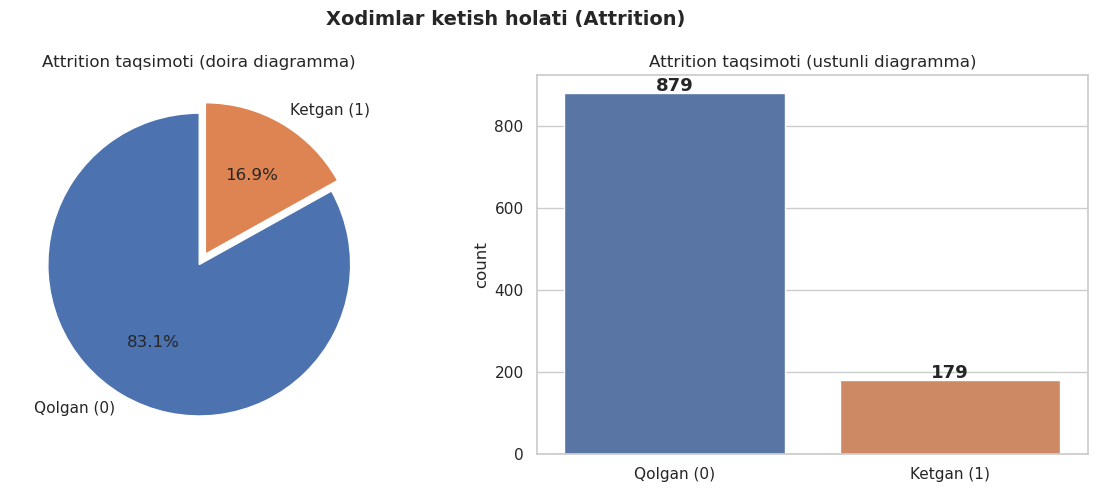

Qolgan xodimlar: 879 (83.1%)
Ketgan xodimlar: 179 (16.9%)


In [15]:
attrition_counts = df['Attrition'].value_counts()
labels = ['Qolgan (0)', 'Ketgan (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    attrition_counts,
    labels=labels,
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90,
    explode=(0, 0.08)
)
axes[0].set_title("Attrition taqsimoti (doira diagramma)")

sns.countplot(x='Attrition', data=df, palette=['#4C72B0', '#DD8452'], ax=axes[1])
axes[1].set_title("Attrition taqsimoti (ustunli diagramma)")
axes[1].set_xticklabels(['Qolgan (0)', 'Ketgan (1)'])
axes[1].set_xlabel("")
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height() + 5),
                     ha='center', fontsize=13, fontweight='bold')

plt.suptitle("Xodimlar ketish holati (Attrition)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Qolgan xodimlar: {attrition_counts[0]} ({attrition_counts[0]/len(df)*100:.1f}%)")
print(f"Ketgan xodimlar: {attrition_counts[1]} ({attrition_counts[1]/len(df)*100:.1f}%)")

## 7. Raqamli ustunlar taqsimoti

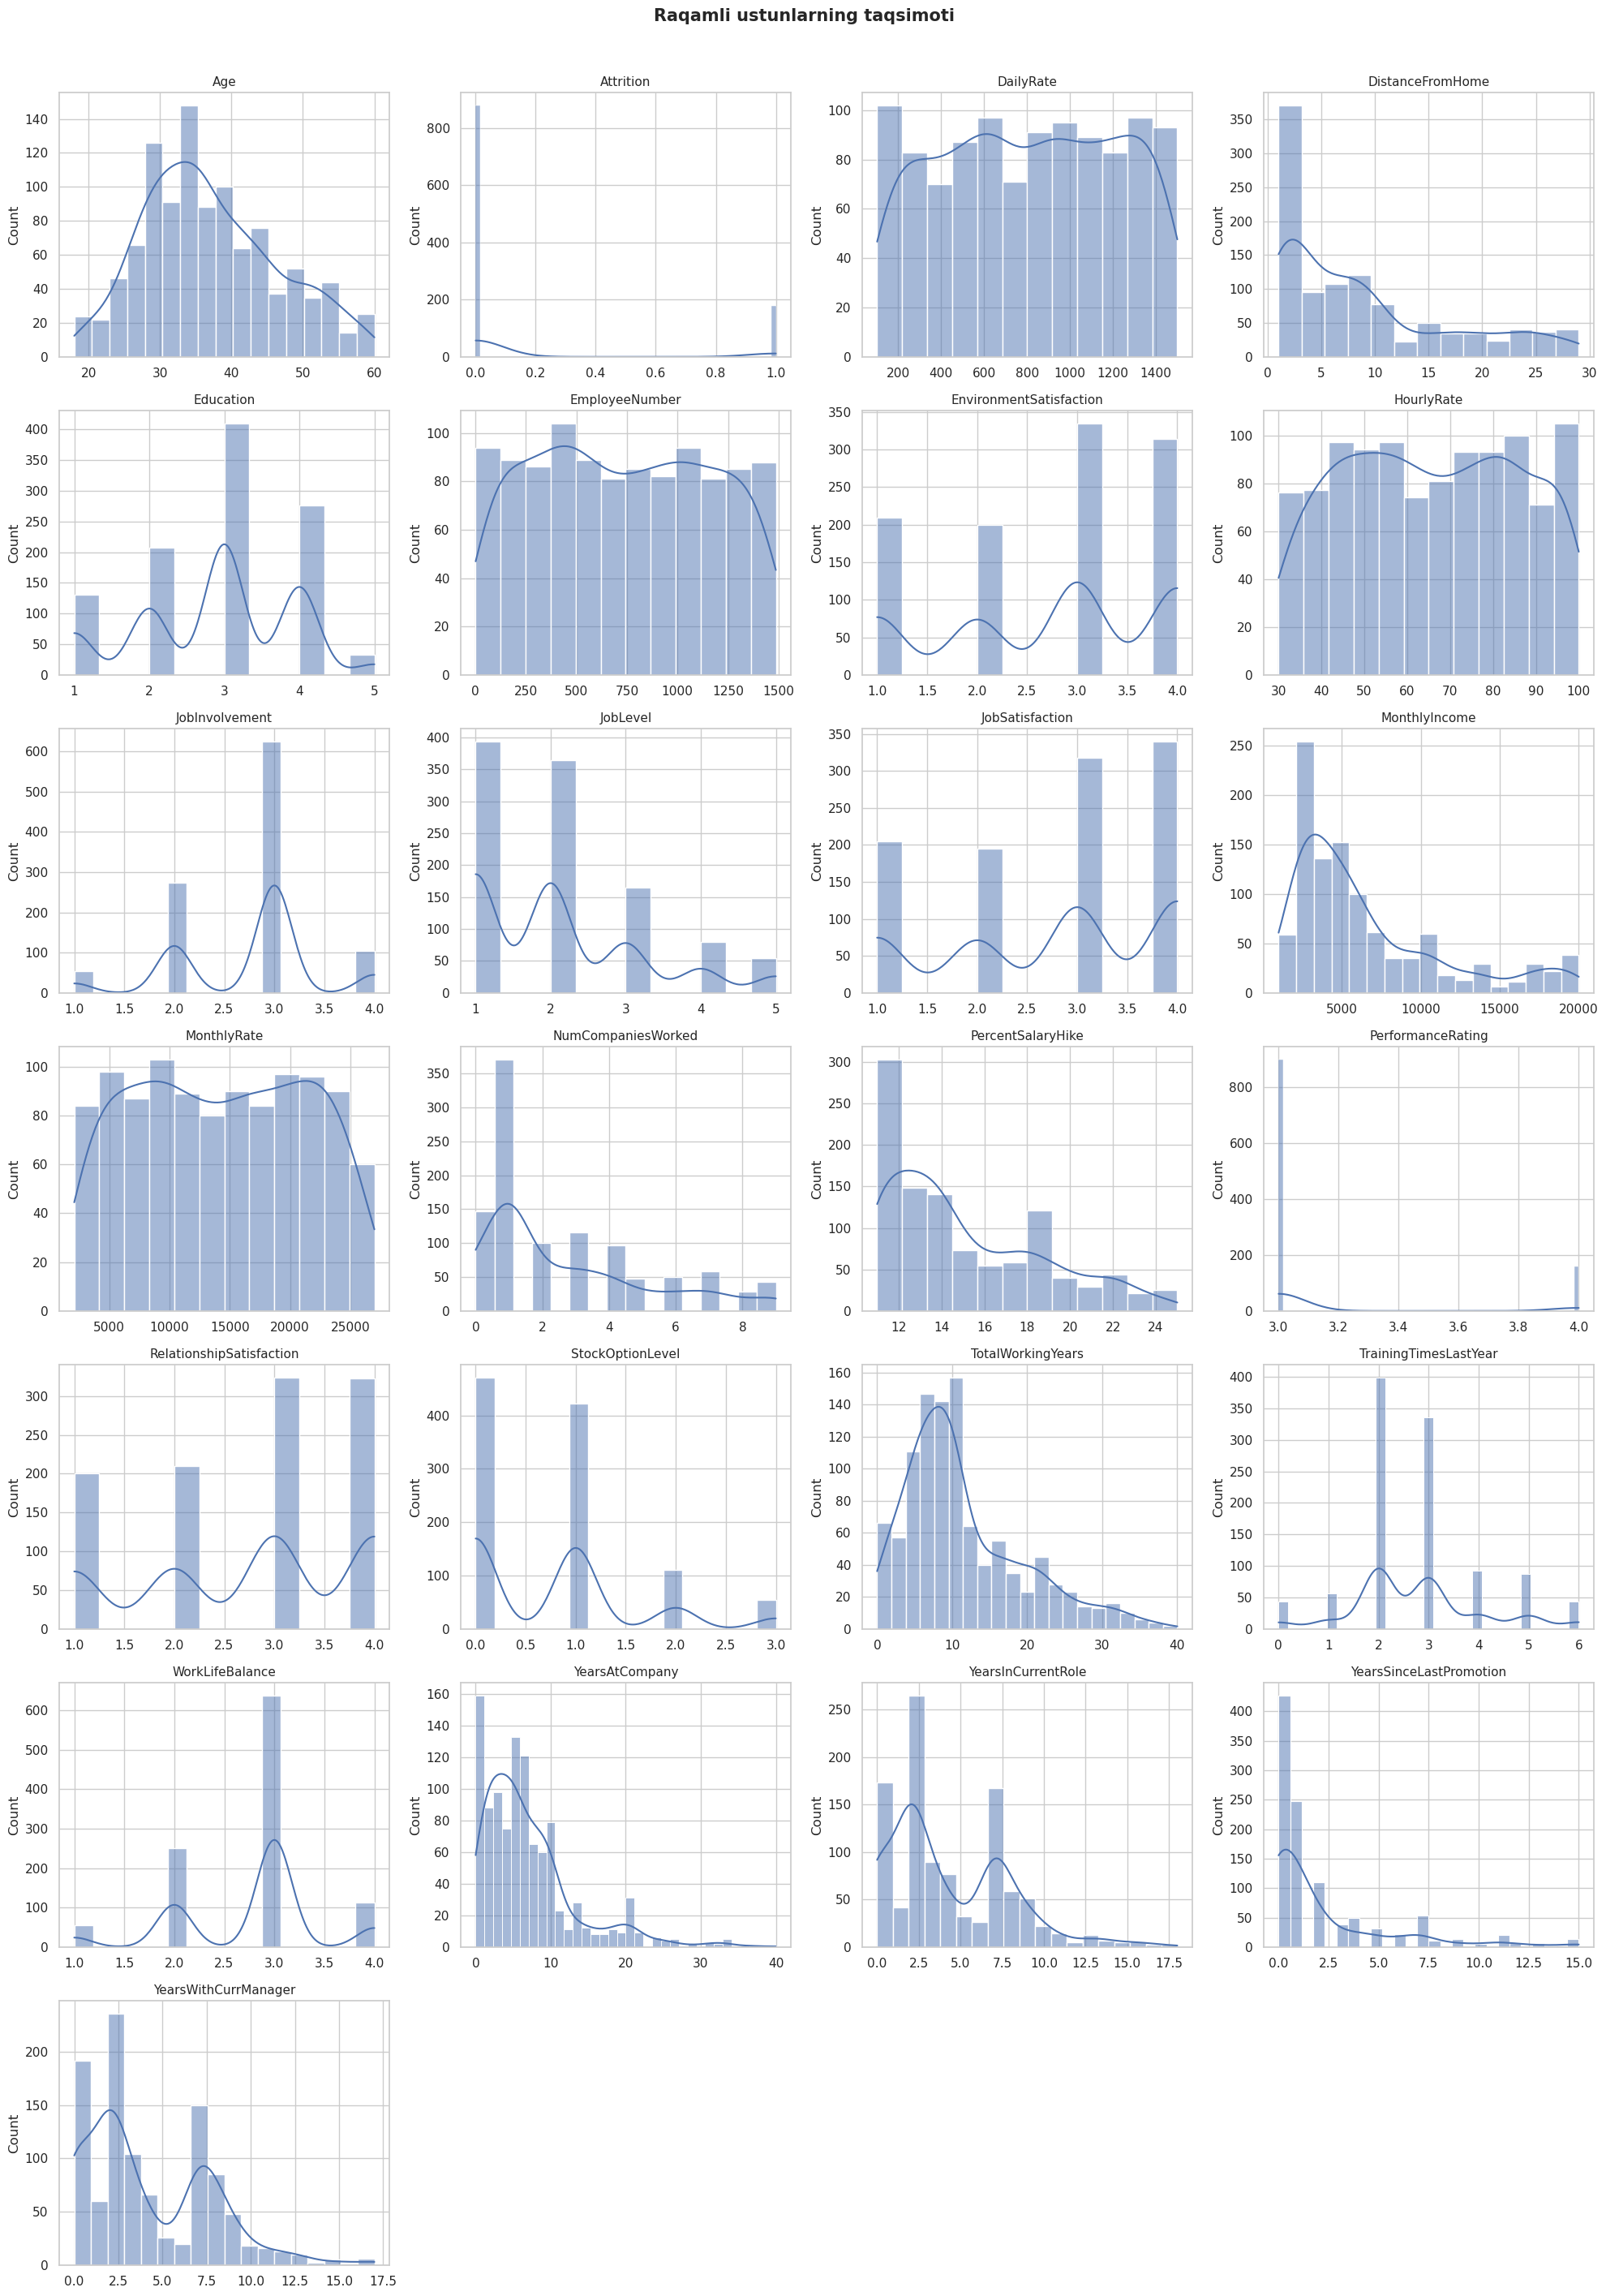

In [16]:
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if df[c].nunique() > 1]

n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Raqamli ustunlarning taqsimoti", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Kategorik ustunlar tahlili

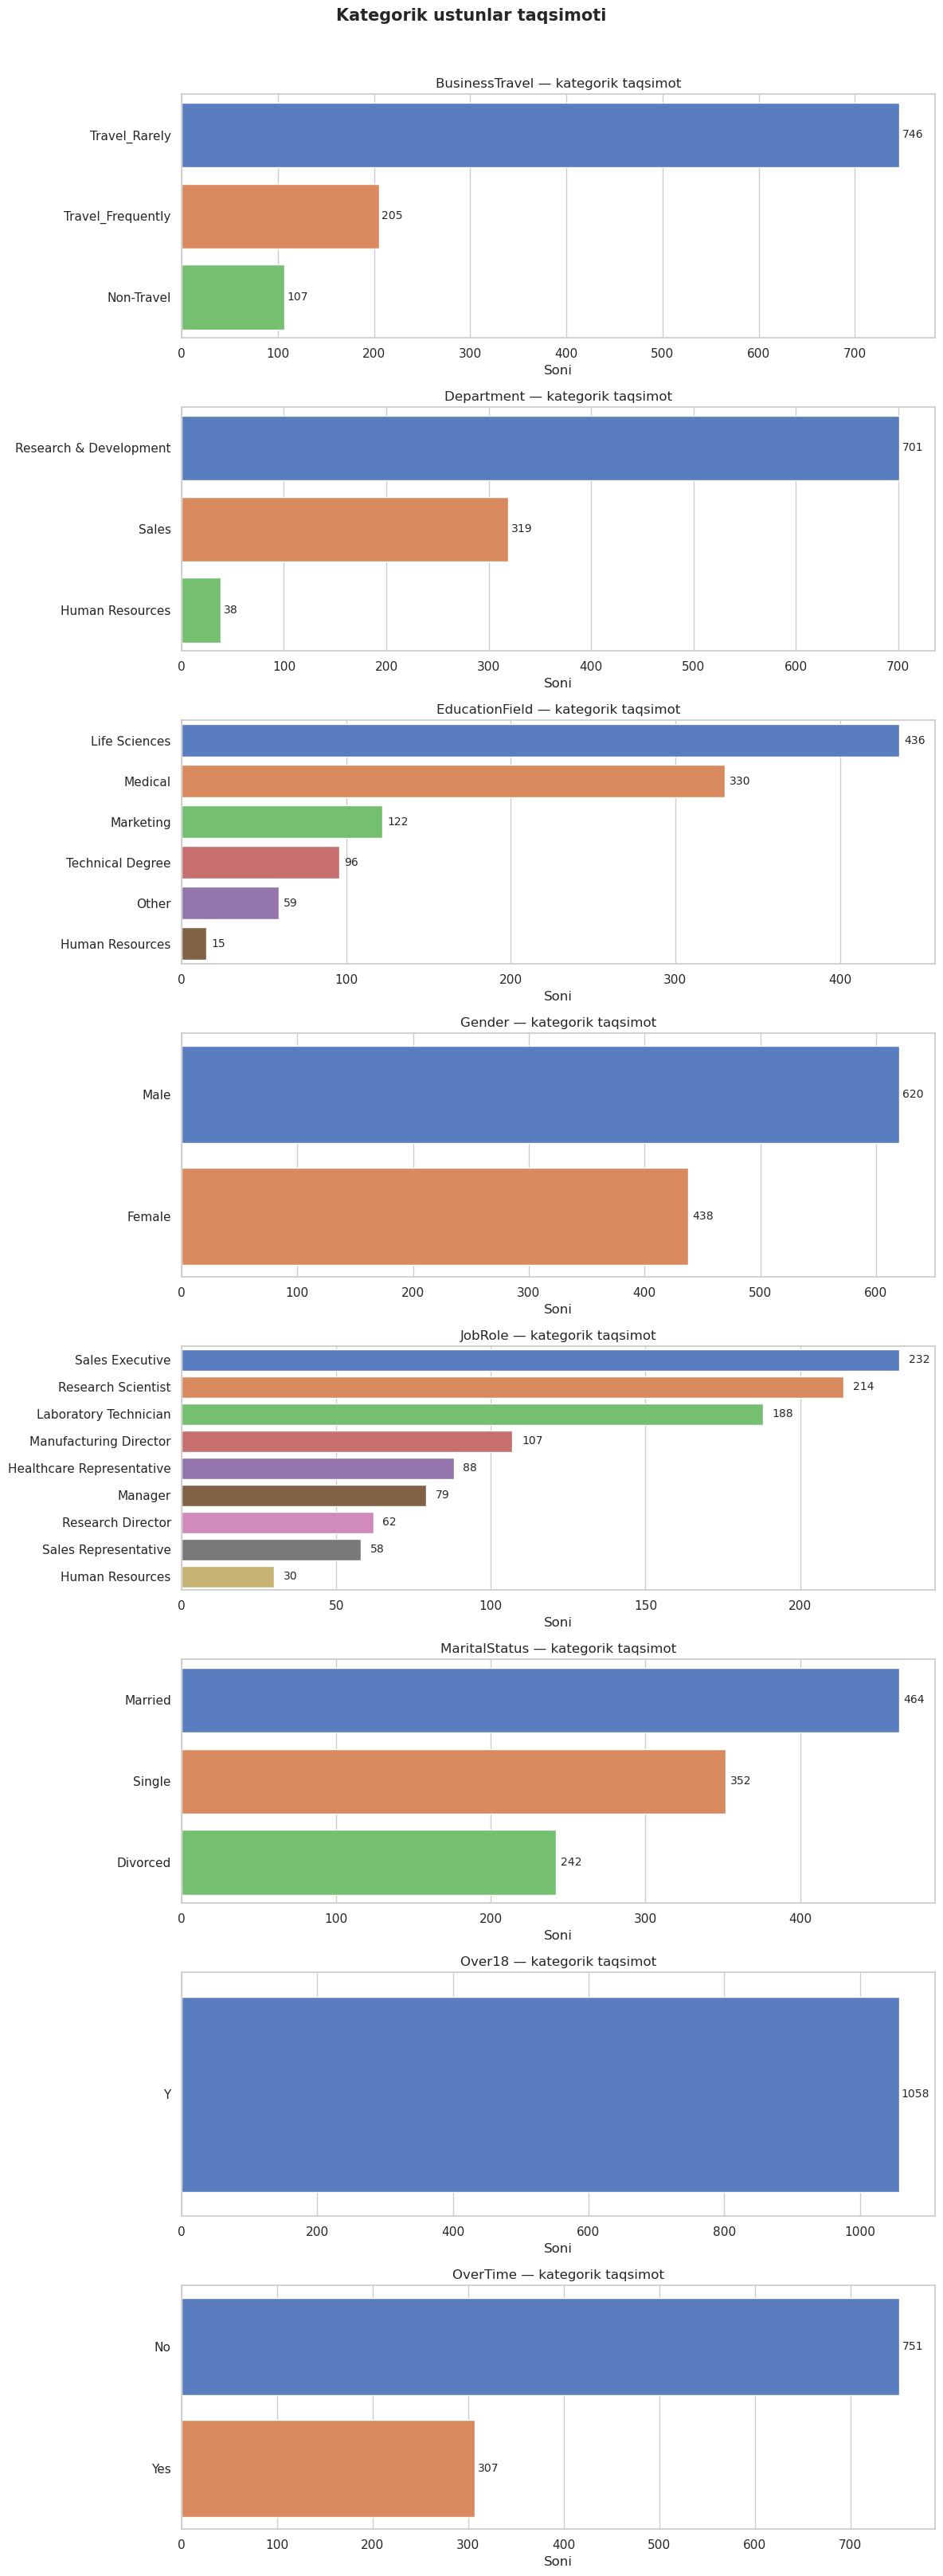

In [17]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, len(cat_cols) * 4))

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, palette='muted', ax=axes[i])
    axes[i].set_title(f"{col} — kategorik taqsimot", fontsize=12)
    axes[i].set_xlabel("Soni")
    axes[i].set_ylabel("")
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_width())}',
                         (p.get_width() + 3, p.get_y() + p.get_height() / 2),
                         va='center', fontsize=10)

plt.suptitle("Kategorik ustunlar taqsimoti", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Kategorik o'zgaruvchilar va Attrition o'rtasidagi bog'liqlik

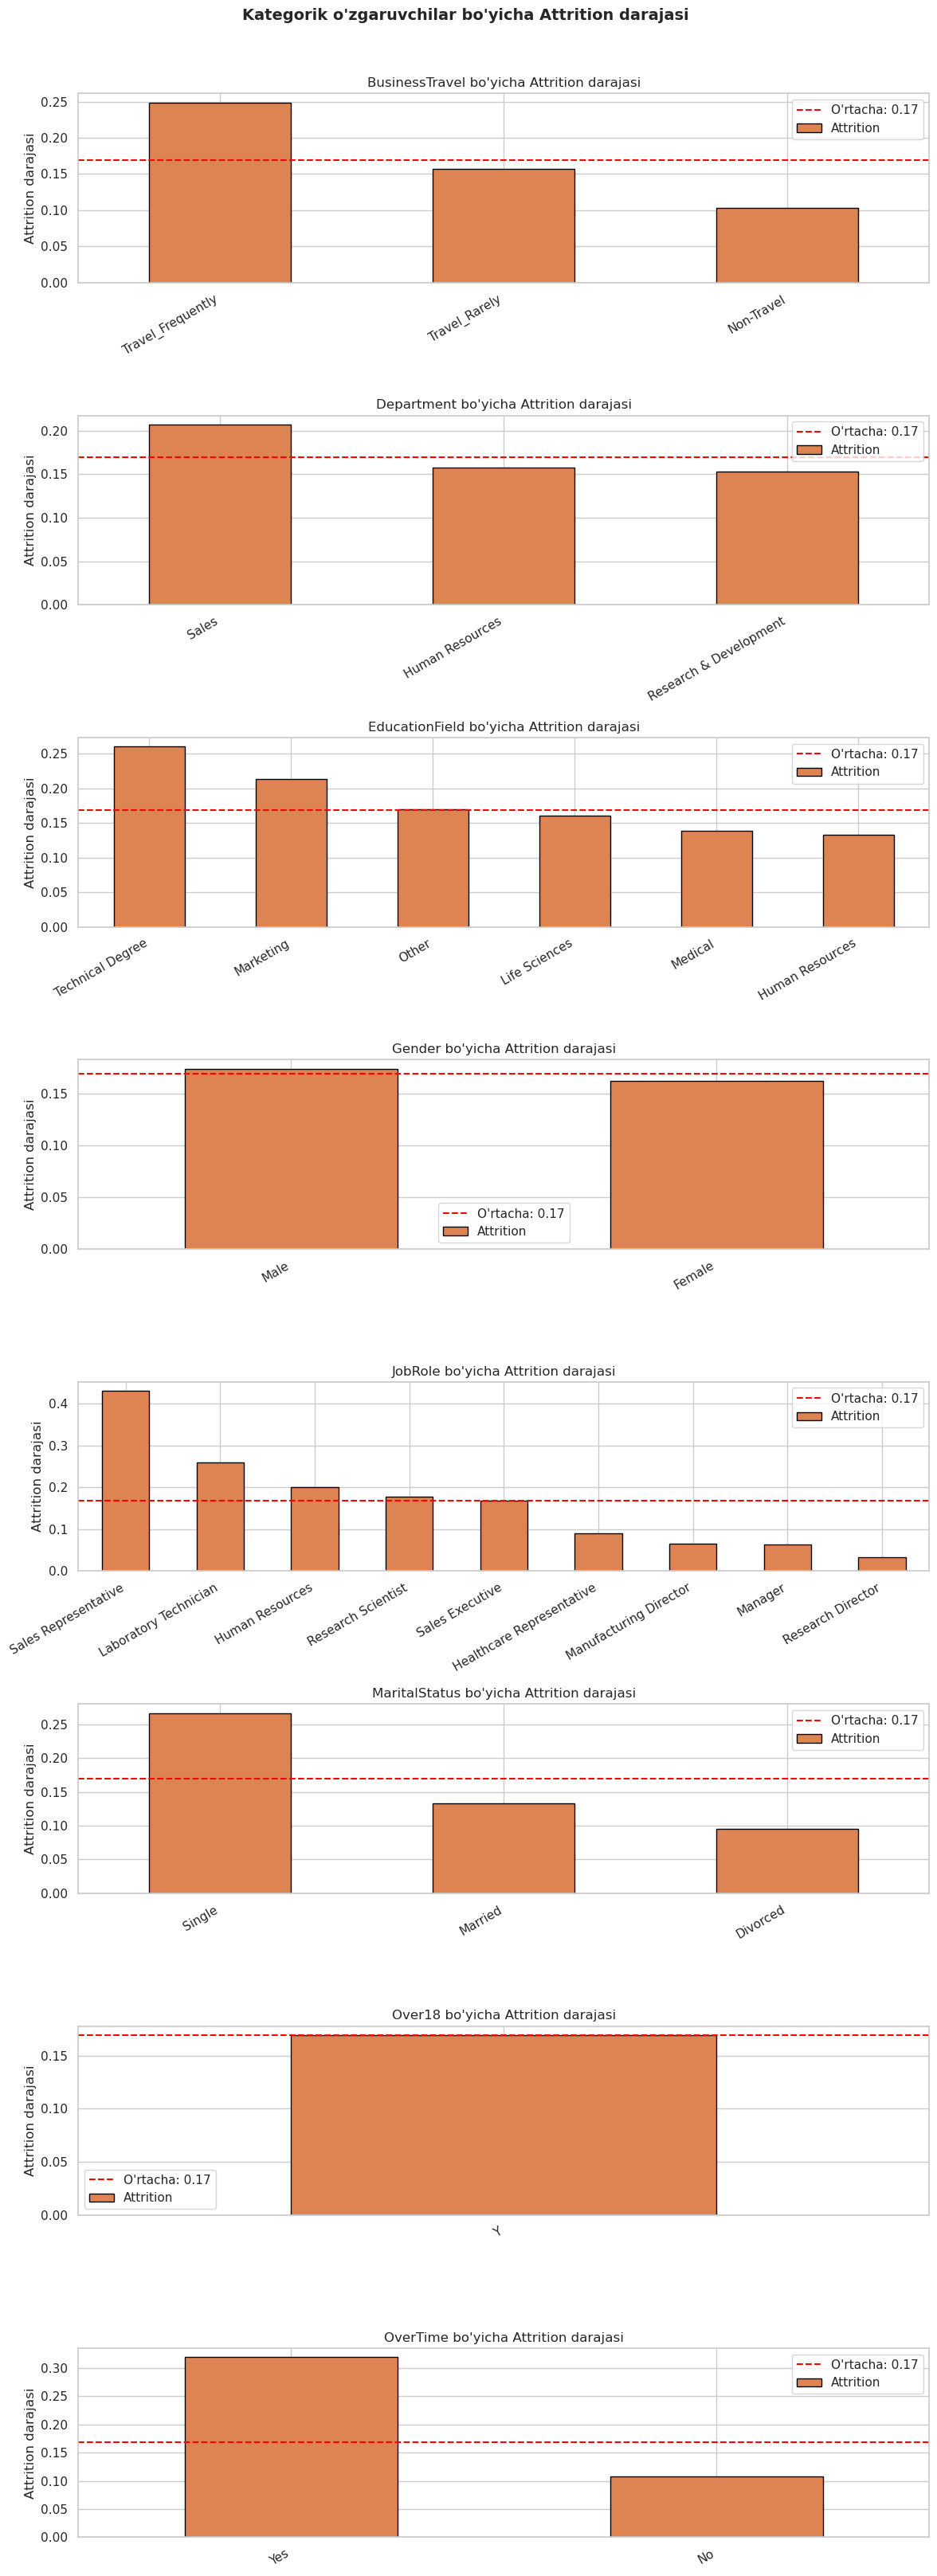

In [18]:
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, len(cat_cols) * 4))

for i, col in enumerate(cat_cols):
    attrition_rate = df.groupby(col)['Attrition'].mean().sort_values(ascending=False)
    attrition_rate.plot(kind='bar', ax=axes[i], color='#DD8452', edgecolor='black')
    axes[i].set_title(f"{col} bo'yicha Attrition darajasi", fontsize=12)
    axes[i].set_ylabel("Attrition darajasi")
    axes[i].set_xlabel("")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].axhline(df['Attrition'].mean(), color='red', linestyle='--', label=f"O'rtacha: {df['Attrition'].mean():.2f}")
    axes[i].legend()

plt.suptitle("Kategorik o'zgaruvchilar bo'yicha Attrition darajasi", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 10. Raqamli o'zgaruvchilar va Attrition o'rtasidagi bog'liqlik (Boxplot)

ValueError: The palette dictionary is missing keys: {'0', '1'}

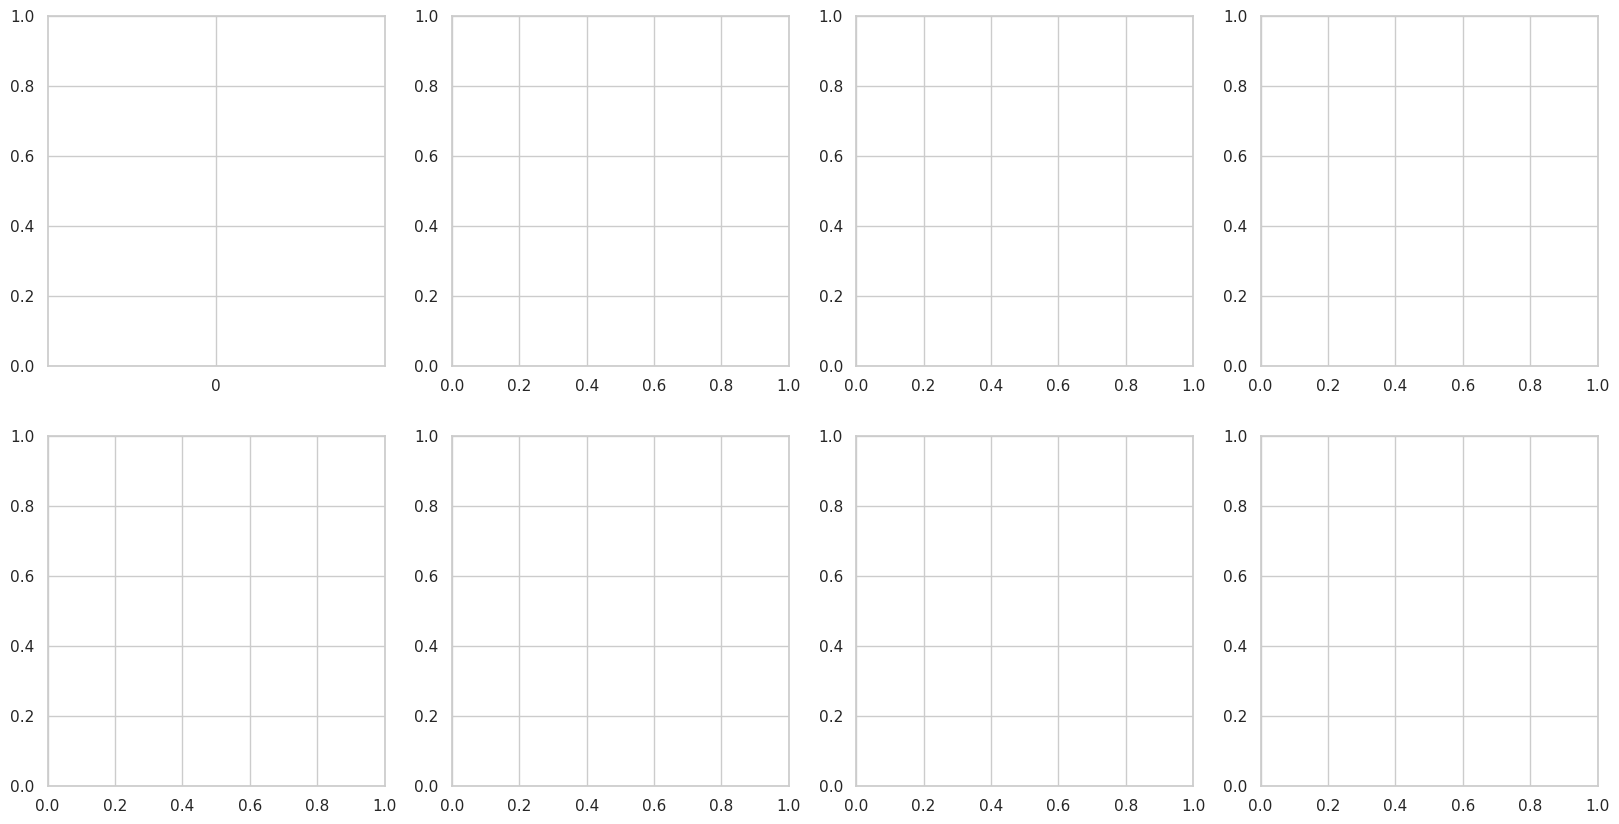

In [19]:
key_num_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                'DistanceFromHome', 'NumCompaniesWorked', 'PercentSalaryHike', 'YearsInCurrentRole']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_num_cols):
    sns.boxplot(x='Attrition', y=col, data=df,
                palette={0: '#4C72B0', 1: '#DD8452'}, ax=axes[i])
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xticklabels(['Qolgan (0)', 'Ketgan (1)'])
    axes[i].set_xlabel("")

plt.suptitle("Raqamli o'zgaruvchilar va Attrition", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Korrelyatsiya matritsasi

In [ ]:
corr = df[num_cols].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.7}
)
plt.title("Raqamli ustunlar korrelyatsiya matritsasi", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Attrition bilan eng yuqori korrelyatsiyaga ega ustunlar

In [ ]:
attrition_corr = df[num_cols].corr()['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in attrition_corr]
attrition_corr.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Attrition bilan korrelyatsiya (raqamli ustunlar)", fontsize=13, fontweight='bold')
plt.xlabel("Korrelyatsiya koeffitsienti")
plt.tight_layout()
plt.show()

print("\nEng yuqori 10 ta korrelyatsiya:")
print(attrition_corr.head(10))

## 13. Bo'lim (Department) va Lavozim (JobRole) bo'yicha tahlil

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dept_attr = df.groupby('Department')['Attrition'].mean().sort_values(ascending=False)
dept_attr.plot(kind='bar', ax=axes[0], color='#4C72B0', edgecolor='black')
axes[0].set_title("Bo'limlar bo'yicha Attrition darajasi", fontsize=12)
axes[0].set_ylabel("Attrition darajasi")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
axes[0].axhline(df['Attrition'].mean(), color='red', linestyle='--', label="O'rtacha")
axes[0].legend()

role_attr = df.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False)
role_attr.plot(kind='barh', ax=axes[1], color='#DD8452', edgecolor='black')
axes[1].set_title("Lavozimlar bo'yicha Attrition darajasi", fontsize=12)
axes[1].set_xlabel("Attrition darajasi")
axes[1].axvline(df['Attrition'].mean(), color='red', linestyle='--', label="O'rtacha")
axes[1].legend()

plt.tight_layout()
plt.show()

## 14. Yosh va Oylik Daromad o'rtasidagi munosabat

In [ ]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['Age'],
    df['MonthlyIncome'],
    c=df['Attrition'],
    cmap='coolwarm',
    alpha=0.6,
    edgecolors='k',
    linewidths=0.3
)
plt.colorbar(scatter, label='Attrition (0=Qolgan, 1=Ketgan)')
plt.xlabel("Yosh (Age)")
plt.ylabel("Oylik daromad (MonthlyIncome)")
plt.title("Yosh va Oylik daromad — Attrition bo'yicha", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Qo'shimcha ish vaqti (OverTime) va Attrition

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

overtime_attr = df.groupby('OverTime')['Attrition'].mean()
overtime_attr.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title("OverTime bo'yicha Attrition darajasi", fontsize=12)
axes[0].set_ylabel("Attrition darajasi")
axes[0].set_xticklabels(["Qo'shimcha ish yo'q", "Qo'shimcha ish bor"], rotation=0)
axes[0].axhline(df['Attrition'].mean(), color='red', linestyle='--', label="O'rtacha")
axes[0].legend()

ct = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
ct.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[1].set_title("OverTime bo'yicha Attrition foizi", fontsize=12)
axes[1].set_ylabel("Foiz (%)")
axes[1].set_xticklabels(["Qo'shimcha ish yo'q", "Qo'shimcha ish bor"], rotation=0)
axes[1].legend(['Qolgan (0)', 'Ketgan (1)'])

plt.tight_layout()
plt.show()

## 16. Qoniqish ko'rsatkichlari tahlili

In [ ]:
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'JobInvolvement']

fig, axes = plt.subplots(1, len(satisfaction_cols), figsize=(20, 5))

for i, col in enumerate(satisfaction_cols):
    sat_attr = df.groupby(col)['Attrition'].mean()
    sat_attr.plot(kind='bar', ax=axes[i], color='#4C72B0', edgecolor='black')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Attrition")
    axes[i].set_xlabel("Daraja")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].axhline(df['Attrition'].mean(), color='red', linestyle='--')

plt.suptitle("Qoniqish ko'rsatkichlari va Attrition", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 17. Ekstremal qiymatlar (Outliers) tekshiruvi

In [ ]:
outlier_cols = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'NumCompaniesWorked', 'DistanceFromHome']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(20, 5))

for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(col, fontsize=11)

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    axes[i].set_xlabel(f"Outlier: {len(outliers)} ta", fontsize=9)

plt.suptitle("Ekstremal qiymatlar (Outliers) — Boxplot", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 18. Asosiy o'zgaruvchilar juft munosabati (Pairplot)

In [ ]:
pair_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'Attrition']
sns.pairplot(df[pair_cols], hue='Attrition', palette={0: '#4C72B0', 1: '#DD8452'},
             plot_kws={'alpha': 0.5}, diag_kind='kde')
plt.suptitle("Asosiy o'zgaruvchilar juft munosabati", y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 19. Asosiy xulosalar va topilmalar

### Dataset haqida:
- Dataset **1058 ta xodim** va **35 ta ustun** dan iborat.
- Datasetda **yo'qolgan qiymatlar yo'q**.
- `EmployeeCount`, `StandardHours`, `Over18` ustunlari faqat bitta qiymatga ega — ular ML uchun foydali emas.

### Attrition (ketish) haqida:
- Xodimlarning **~16.9%** ish joyini tark etgan — bu **disbalans** mavjudligini ko'rsatadi.
- **Qo'shimcha ish vaqti (OverTime)** bor xodimlar ancha ko'proq ketgan.
- **Yoshi kichik** va **daromadi past** xodimlar ko'proq ketgan.
- **Sales Representative** va **Laboratory Technician** lavozimidagi xodimlar eng ko'p ketgan.

### Muhim omillar:
- `MonthlyIncome`, `TotalWorkingYears`, `Age` — ketmaslikka ijobiy ta'sir ko'rsatadi.
- `OverTime`, `DistanceFromHome` — ketishga salbiy ta'sir ko'rsatadi.
- `JobSatisfaction` va `EnvironmentSatisfaction` darajasi **1** bo'lganda ketish ko'proq.

### Keyingi qadamlar:
1. `EmployeeCount`, `StandardHours`, `Over18` ustunlarini o'chirish.
2. Kategorik ustunlarni **Label Encoding** yoki **One-Hot Encoding** qilish.
3. Disbalansni hal qilish uchun **SMOTE** yoki `class_weight` ishlatish.
4. ML modellari: Logistic Regression, Random Forest, XGBoost.